# Dataset 1 (Seeds) - Edge Detection Parameter Experimentation
Use this notebook to load individual images from Dataset 1 and dynamically test different parameters for Preprocessing, Canny, and Sobel edge detection.

In [3]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

# Import our existing pipeline code
from baseline_code.preprocessing import load_config, apply_grayscale, apply_noise_reduction
from edge_detection import apply_canny, apply_sobel, extract_contours_and_features, count_objects_from_contours

In [4]:
# --- CONFIGURATION ---
IMAGE_NAME = '100.jpg' # Change this to any seed image name (e.g., '14.jpg', '50.jpg')
DATA_DIR = 'data/'
CONFIG_PATH = 'baseline_code/config.yaml'

# Load image and config
cfg = load_config(CONFIG_PATH)
img_path = os.path.join(DATA_DIR, IMAGE_NAME)
image = cv2.imread(img_path)

if image is None:
    print(f"Error: Could not find {img_path}")
else:
    print(f"Loaded {IMAGE_NAME} with shape {image.shape}")

Loaded 100.jpg with shape (3024, 3024, 3)


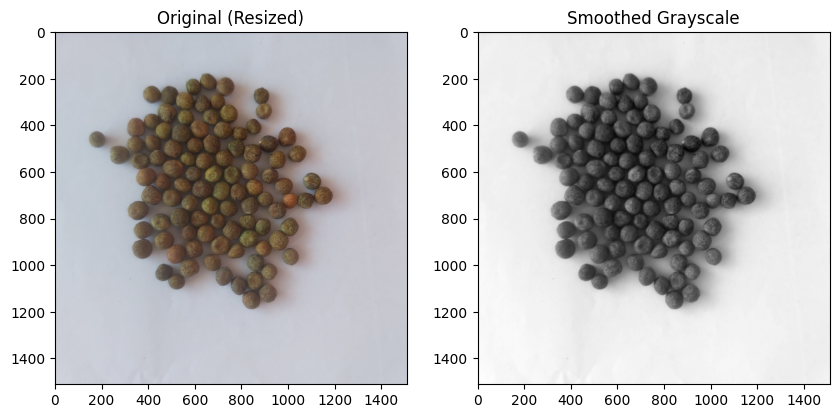

In [5]:
# 1. Downsampling (Matching our processing script)
RESIZE_FACTOR = 0.5
h, w = image.shape[:2]
new_w, new_h = int(w * RESIZE_FACTOR), int(h * RESIZE_FACTOR)
image_resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_AREA)

# 2. Preprocessing
gray = apply_grayscale(image_resized)
smoothed = apply_noise_reduction(gray, cfg, method="gaussian")

# Display intermediate steps
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original (Resized)")
ax[1].imshow(smoothed, cmap='gray')
ax[1].set_title("Smoothed Grayscale")
plt.show()

## Canny Edge Detection
Try tweaking the `low_thresh` and `high_thresh` values below!

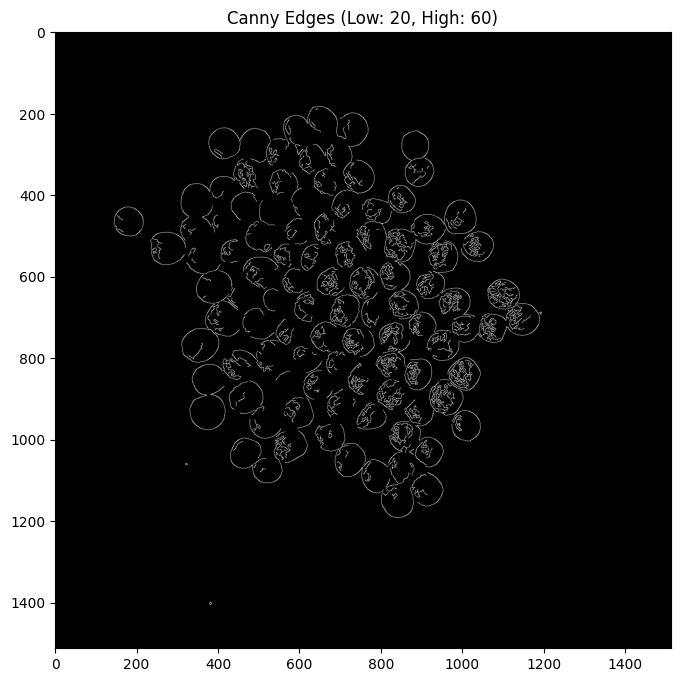

In [6]:
# --- CANNY EXPERIMENTATION PARAMETERS ---
LOW_THRESH = 20
HIGH_THRESH = 60

canny_edges = apply_canny(smoothed, low_thresh=LOW_THRESH, high_thresh=HIGH_THRESH)

plt.figure(figsize=(8, 8))
plt.imshow(canny_edges, cmap='gray')
plt.title(f"Canny Edges (Low: {LOW_THRESH}, High: {HIGH_THRESH})")
plt.show()

## Sobel Edge Detection
Try tweaking `ksize` (must be odd, 1, 3, 5, 7) or the threshold applied to the floating-point magnitude map

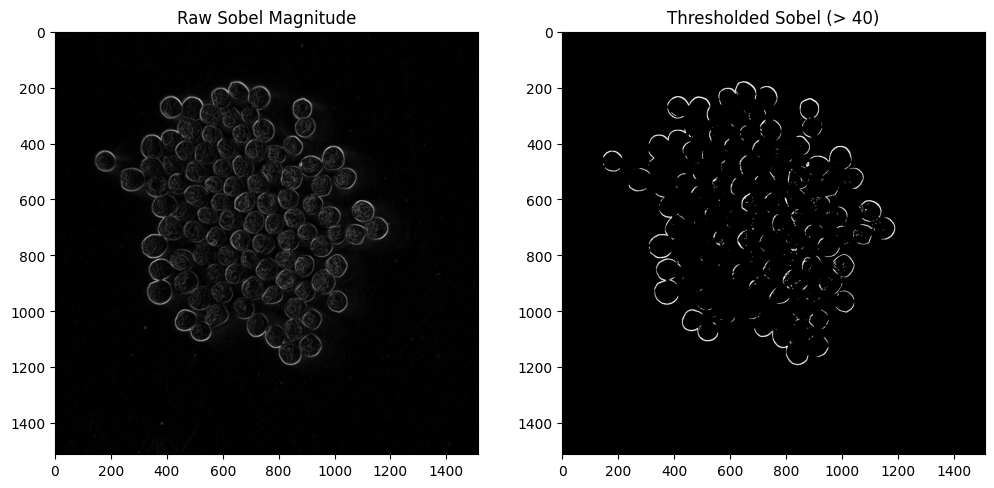

In [7]:
# --- SOBEL EXPERIMENTATION PARAMETERS ---
SOBEL_KSIZE = 3
SOBEL_BINARY_THRESH = 40  # Turning raw gradients into a binary mask

_, _, sobel_edges = apply_sobel(smoothed, ksize=SOBEL_KSIZE)
_, sobel_binary = cv2.threshold(sobel_edges, SOBEL_BINARY_THRESH, 255, cv2.THRESH_BINARY)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(sobel_edges, cmap='gray')
ax[0].set_title("Raw Sobel Magnitude")
ax[1].imshow(sobel_binary, cmap='gray')
ax[1].set_title(f"Thresholded Sobel (> {SOBEL_BINARY_THRESH})")
plt.show()

## Evaluate & Count
Let's extract the contours and run our area threshold count based on the edge maps generated above.

In [8]:
# Extract features
canny_contours, canny_features = extract_contours_and_features(canny_edges, method='canny')
sobel_contours, sobel_features = extract_contours_and_features(sobel_binary, method='sobel')

# Scale thresholds by resize factor 
scaled_min_area = (cfg.get("blob_detection", {}).get("min_area", 8000) * (RESIZE_FACTOR ** 2)) / 2
scaled_max_area = cfg.get("blob_detection", {}).get("max_area", 200000) * (RESIZE_FACTOR ** 2)

canny_count = count_objects_from_contours(canny_features, min_area=scaled_min_area, max_area=scaled_max_area, min_circ=0.2)
sobel_count = count_objects_from_contours(sobel_features, min_area=scaled_min_area, max_area=scaled_max_area, min_circ=0.2)

print(f"Canny Predicted Count: {canny_count}")
print(f"Sobel Predicted Count: {sobel_count}")

# Draw the Canny Contours explicitly in Green
vis_image = image_resized.copy()
canny_contours_to_draw = [f['contour'] for f in canny_features]
cv2.drawContours(vis_image, canny_contours_to_draw, -1, (0, 255, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
plt.title("Visualizing Canny Extracted Contours")
plt.show()

TypeError: extract_contours_and_features() got an unexpected keyword argument 'method'